# AWQ vs FP16 vs INT8 BNB on A100 Benchmark


**Main goals**
1. Use a cleaner software stack for AutoAWQ.
2. Benchmark FP16 and AWQ fairly with warmups, longer generation, and multiple batch sizes.
3. Measure memory, power, throughput, and tokens/sec/W.
4. Print layer/module types to confirm the AWQ model is actually using quantized layers.

**How to use**
- In Colab: `Runtime → Change runtime type → A100 GPU`
- Then: `Runtime → Restart session`
- Run this notebook from top to bottom.


## 0. Check GPU

Make sure you are actually on A100 before spending time running the full benchmark.


In [1]:
!nvidia-smi

Tue Jun  9 01:36:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   45C    P0             57W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 1. Clean install

This deliberately avoids doing `pip install -U transformers` after AutoAWQ. AutoAWQ has compatibility issues with some newer stacks, so this notebook pins the stack closer to the last tested AutoAWQ configuration.

After this cell finishes, Colab may ask you to restart the runtime. If it does, restart and run from the top again.


In [2]:
# old packages that can conflict
!pip uninstall -y -q autoawq awq transformers accelerate bitsandbytes optimum auto-gptq gptqmodel

# Install a stack closer to AutoAWQ's last tested config.
!pip install -q "torch" "torchvision" "torchaudio"

!pip install -q "transformers==4.51.3" "accelerate" "huggingface_hub" "safetensors" "sentencepiece" "protobuf"
!pip install -q "autoawq"
!pip install -q "bitsandbytes" "nvidia-ml-py3" "pandas" "matplotlib"

import torch, transformers, sys, platform
print("Python:", sys.version)
print("Platform:", platform.platform())
print("Torch:", torch.__version__)
print("CUDA used by torch:", torch.version.cuda)
print("Transformers:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 123.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 121.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 19.6 MB/s eta 0:00:00
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
Torch: 2.11.0+cu128
CUDA used by torch: 12.8
Transformers: 4.51.3
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


## 2. Login to Hugging Face



In [3]:
# from huggingface_hub import login
# login()

## 3. Configuration



In [4]:
import os, gc, time, threading, math, warnings, subprocess, json
from collections import Counter
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

BASE_MODEL = "meta-llama/Meta-Llama-3.1-8B-Instruct"
AWQ_MODEL  = "hugging-quants/Meta-Llama-3.1-8B-Instruct-AWQ-INT4"

USER_PROMPT = "Explain algorithm-hardware co-design for efficient LLM inference in one paragraph."

MAX_NEW_TOKENS = 512
NUM_RUNS = 10
WARMUP_RUNS = 3
BATCH_SIZES = [1, 2, 4, 8]

# If batch 8 OOMs, reduce to [1,2,4].
DO_SAMPLE = False
USE_CACHE = True

# Power sampling
POWER_SAMPLE_INTERVAL_SEC = 0.05
IDLE_POWER_SECONDS = 5.0

# For reproducibility
torch.manual_seed(0)
np.random.seed(0)
torch.backends.cuda.matmul.allow_tf32 = True

print("BASE_MODEL:", BASE_MODEL)
print("AWQ_MODEL:", AWQ_MODEL)
print("MAX_NEW_TOKENS:", MAX_NEW_TOKENS)
print("BATCH_SIZES:", BATCH_SIZES)


BASE_MODEL: meta-llama/Meta-Llama-3.1-8B-Instruct
AWQ_MODEL: hugging-quants/Meta-Llama-3.1-8B-Instruct-AWQ-INT4
MAX_NEW_TOKENS: 512
BATCH_SIZES: [1, 2, 4, 8]


## 4. Utility functions

These functions measure:
- tokens/sec
- average GPU power
- dynamic power after subtracting idle power
- peak GPU memory
- efficiency in tokens/sec/W


In [5]:
from transformers import AutoTokenizer, AutoModelForCausalLM

def clear_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

def get_model_device(model):
    try:
        return model.device
    except Exception:
        try:
            return next(model.parameters()).device
        except Exception:
            return torch.device("cuda:0")

def nvidia_smi_power_watts():
    # Query instantaneous power draw in W.
    try:
        out = subprocess.check_output(
            [
                "nvidia-smi",
                "--query-gpu=power.draw",
                "--format=csv,noheader,nounits",
            ],
            encoding="utf-8"
        ).strip().splitlines()[0]
        return float(out)
    except Exception:
        return float("nan")

def sample_power_until(stop_event, samples, interval=0.05):
    while not stop_event.is_set():
        samples.append((time.perf_counter(), nvidia_smi_power_watts()))
        time.sleep(interval)

def measure_idle_power(seconds=5.0, interval=0.05):
    clear_gpu()
    samples = []
    t0 = time.perf_counter()
    while time.perf_counter() - t0 < seconds:
        samples.append(nvidia_smi_power_watts())
        time.sleep(interval)
    samples = [x for x in samples if not math.isnan(x)]
    return float(np.mean(samples)) if samples else float("nan")

def make_prompt_text(tokenizer):
    messages = [{"role": "user", "content": USER_PROMPT}]
    if hasattr(tokenizer, "apply_chat_template") and tokenizer.chat_template is not None:
        return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    return USER_PROMPT

def make_batch(tokenizer, batch_size):
    prompt = make_prompt_text(tokenizer)
    prompts = [prompt] * batch_size
    # Left padding is usually preferred for decoder-only batch generation
    tokenizer.padding_side = "left"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    return tokenizer(prompts, return_tensors="pt", padding=True)

def print_module_summary(model, title="", max_lines=40):
    print("\n" + "="*80)
    print(title)
    print("="*80)
    try:
        counts = Counter(type(m).__name__ for m in model.modules())
        for name, count in counts.most_common(max_lines):
            print(f"{name:45s} {count}")
    except Exception as e:
        print("Could not summarize modules:", repr(e))

def benchmark_generate(model, tokenizer, label, batch_size=1, idle_power_w=None):
    clear_gpu()
    device = get_model_device(model)
    inputs = make_batch(tokenizer, batch_size).to(device)
    prompt_len = inputs.input_ids.shape[1]

    gen_kwargs = dict(
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=DO_SAMPLE,
        use_cache=USE_CACHE,
        pad_token_id=tokenizer.eos_token_id,
    )

    # Warmup
    for _ in range(WARMUP_RUNS):
        with torch.inference_mode():
            _ = model.generate(**inputs, **gen_kwargs)
        torch.cuda.synchronize()

    clear_gpu()
    power_samples = []
    run_times = []
    new_token_counts = []

    for run in range(NUM_RUNS):
        stop_event = threading.Event()
        power_thread = threading.Thread(
            target=sample_power_until,
            args=(stop_event, power_samples, POWER_SAMPLE_INTERVAL_SEC),
        )

        torch.cuda.synchronize()
        power_thread.start()
        t0 = time.perf_counter()

        with torch.inference_mode():
            out = model.generate(**inputs, **gen_kwargs)

        torch.cuda.synchronize()
        t1 = time.perf_counter()
        stop_event.set()
        power_thread.join()

        elapsed = t1 - t0
        # Count only generated tokens, multiplied by batch.
        new_tokens_per_sequence = out.shape[1] - prompt_len
        new_tokens = int(new_tokens_per_sequence * batch_size)

        run_times.append(elapsed)
        new_token_counts.append(new_tokens)

        print(f"{label} | bs={batch_size} | run {run+1}/{NUM_RUNS}: "
              f"{new_tokens/elapsed:.2f} tok/s, {elapsed:.2f}s")

    valid_power = [p for _, p in power_samples if not math.isnan(p)]
    avg_power_w = float(np.mean(valid_power)) if valid_power else float("nan")
    dynamic_power_w = avg_power_w - idle_power_w if idle_power_w is not None and not math.isnan(idle_power_w) else float("nan")
    dynamic_power_w = max(dynamic_power_w, 1e-9) if not math.isnan(dynamic_power_w) else float("nan")

    total_tokens = int(np.sum(new_token_counts))
    total_time = float(np.sum(run_times))
    throughput = total_tokens / total_time
    peak_mem_gb = torch.cuda.max_memory_allocated() / 1024**3 if torch.cuda.is_available() else float("nan")

    result = {
        "label": label,
        "batch_size": batch_size,
        "max_new_tokens": MAX_NEW_TOKENS,
        "num_runs": NUM_RUNS,
        "warmup_runs": WARMUP_RUNS,
        "total_generated_tokens": total_tokens,
        "total_time_s": total_time,
        "throughput_tok_s": throughput,
        "avg_power_w": avg_power_w,
        "idle_power_w": idle_power_w,
        "dynamic_power_w": dynamic_power_w,
        "tok_s_per_total_w": throughput / avg_power_w if avg_power_w and not math.isnan(avg_power_w) else float("nan"),
        "tok_s_per_dynamic_w": throughput / dynamic_power_w if dynamic_power_w and not math.isnan(dynamic_power_w) else float("nan"),
        "peak_memory_gb": peak_mem_gb,
    }
    return result

def plot_results(df, suffix=""):
    metrics = [
        ("throughput_tok_s", "Throughput (tokens/sec)"),
        ("peak_memory_gb", "Peak GPU Memory (GB)"),
        ("avg_power_w", "Average Power (W)"),
        ("tok_s_per_dynamic_w", "Efficiency (tokens/sec/dynamic W)"),
    ]
    for col, title in metrics:
        plt.figure(figsize=(10, 4))
        labels = df["label"] + "-bs" + df["batch_size"].astype(str)
        plt.bar(labels, df[col])
        plt.xticks(rotation=45, ha="right")
        plt.ylabel(title)
        plt.title(title + suffix)
        plt.tight_layout()
        plt.show()


## 5. Measure idle GPU power

This lets us compute a more meaningful dynamic-power efficiency.


In [6]:
idle_power_w = measure_idle_power(IDLE_POWER_SECONDS, POWER_SAMPLE_INTERVAL_SEC)
print(f"Idle GPU power: {idle_power_w:.2f} W")

Idle GPU power: 63.97 W


## 6. Load and benchmark FP16 baseline

This is the strong A100 Tensor Core baseline. We use `torch_dtype=torch.float16`.


In [7]:
clear_gpu()

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import pandas as pd

tokenizer_fp16 = AutoTokenizer.from_pretrained(
    BASE_MODEL,
    trust_remote_code=True,
    token=True,
)

if tokenizer_fp16.pad_token is None:
    tokenizer_fp16.pad_token = tokenizer_fp16.eos_token

tokenizer_fp16.padding_side = "left"

model_fp16 = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16,
    device_map={"": 0},
    trust_remote_code=True,
    token=True,
)

model_fp16.eval()

print("FP16 8B model loaded successfully")
print_module_summary(model_fp16, title="FP16 module summary")
print("FP16 device:", get_model_device(model_fp16))
print("FP16 dtype sample:", next(model_fp16.parameters()).dtype)

fp16_results = []

for bs in BATCH_SIZES:
    try:
        result = benchmark_generate(
            model_fp16,
            tokenizer_fp16,
            "FP16",
            batch_size=bs,
            idle_power_w=idle_power_w
        )
        fp16_results.append(result)

    except torch.cuda.OutOfMemoryError:
        print(f"OOM for FP16 batch size {bs}. Skipping.")
        clear_gpu()

df_fp16 = pd.DataFrame(fp16_results)
display(df_fp16)

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:636: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


FP16 | bs=8 | run 9/10: 217.77 tok/s, 7.71s


/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:636: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


FP16 | bs=8 | run 10/10: 216.78 tok/s, 7.75s


,label,batch_size,max_new_tokens,num_runs,warmup_runs,total_generated_tokens,total_time_s,throughput_tok_s,avg_power_w,idle_power_w,dynamic_power_w,tok_s_per_total_w,tok_s_per_dynamic_w,peak_memory_gb
0,FP16,1,512,10,3,2100,75.756593,27.720360,156.157585,63.97194,92.185645,0.177515,0.300701,15.001884
1,FP16,2,512,10,3,4200,77.210016,54.397088,157.230923,63.97194,93.258983,0.345969,0.583291,15.080798
2,FP16,4,512,10,3,8400,76.500296,109.803497,162.892867,63.97194,98.920927,0.674084,1.110013,15.111137
3,FP16,8,512,10,3,16800,76.992211,218.203891,172.863100,63.97194,108.891160,1.262293,2.003871,15.256435


## 7. Free FP16 model before loading AWQ



In [8]:
del model_fp16
gc.collect()
clear_gpu()
!nvidia-smi""

Tue Jun  9 02:05:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   46C    P0             64W /  400W |   15840MiB /  81920MiB |     10%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 8. Load and benchmark AWQ, standard fused path

Important settings:
- `fuse_layers=True` is often needed for AutoAWQ speed.
- `safetensors=True`
- `device_map="cuda:0"`

The module summary should show quantized/AWQ modules, not only normal `Linear` modules.


In [9]:
from awq import AutoAWQForCausalLM
from transformers import AutoTokenizer
import torch

tokenizer_awq = AutoTokenizer.from_pretrained(
    AWQ_MODEL,
    trust_remote_code=True,
    token=True,
)

if tokenizer_awq.pad_token is None:
    tokenizer_awq.pad_token = tokenizer_awq.eos_token

tokenizer_awq.padding_side = "left"

model_awq = AutoAWQForCausalLM.from_quantized(
    AWQ_MODEL,
    fuse_layers=True,
    trust_remote_code=True,
    safetensors=True,
    device_map={"": 0},
)

model_awq.eval()

print("AWQ 8B model loaded successfully")

/usr/local/lib/python3.12/dist-packages/awq/__init__.py:21: DeprecationWarning: 
I have left this message as the final dev message to help you transition.

Important Notice:
- AutoAWQ is officially deprecated and will no longer be maintained.
- The last tested configuration used Torch 2.6.0 and Transformers 4.51.3.
- If future versions of Transformers break AutoAWQ compatibility, please report the issue to the Transformers project.

Alternative:
- AutoAWQ has been adopted by the vLLM Project: https://github.com/vllm-project/llm-compressor

For further inquiries, feel free to reach out:
- X: https://x.com/casper_hansen_
- LinkedIn: https://www.linkedin.com/in/casper-hansen-804005170/

  warnings.warn(_FINAL_DEV_MESSAGE, category=DeprecationWarning, stacklevel=1)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/295 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/1.05G [00:00<?, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

Replacing layers...: 100%|██████████| 32/32 [00:13<00:00,  2.41it/s]


AWQ 8B model loaded successfully


/usr/local/lib/python3.12/dist-packages/awq/models/base.py:541: UserWarning: Skipping fusing modules because AWQ extension is not installed.No module named 'awq_ext'
  warnings.warn("Skipping fusing modules because AWQ extension is not installed." + msg)


In [10]:
import time, gc
import torch
import pandas as pd

def clear_gpu():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

def get_model_device(model):
    try:
        return model.device
    except Exception:
        return next(model.parameters()).device

def make_batch(tokenizer, batch_size, user_prompt=None):
    if user_prompt is None:
        user_prompt = "Explain quantization for large language model inference in simple terms."

    try:
        messages = [{"role": "user", "content": user_prompt}]
        prompt = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )
    except Exception:
        prompt = user_prompt

    prompts = [prompt] * batch_size

    return tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True
    )

def measure_gpu_power_w():
    try:
        import subprocess
        result = subprocess.check_output(
            [
                "nvidia-smi",
                "--query-gpu=power.draw",
                "--format=csv,noheader,nounits"
            ]
        )
        return float(result.decode().strip().split("\n")[0])
    except Exception:
        return float("nan")

def benchmark_generate(
    model,
    tokenizer,
    label,
    batch_size=1,
    max_new_tokens=512,
    warmup_runs=3,
    num_runs=10,
    idle_power_w=0.0,
):
    clear_gpu()

    device = get_model_device(model)

    inputs = make_batch(tokenizer, batch_size).to(device)
    prompt_len = inputs.input_ids.shape[1]

    gen_kwargs = dict(
        max_new_tokens=max_new_tokens,
        do_sample=False,
        use_cache=True,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

    # Warmup
    for _ in range(warmup_runs):
        with torch.inference_mode():
            _ = model.generate(**inputs, **gen_kwargs)
        torch.cuda.synchronize()

    times = []
    powers = []
    total_new_tokens = None

    for _ in range(num_runs):
        torch.cuda.synchronize()
        p0 = measure_gpu_power_w()
        t0 = time.perf_counter()

        with torch.inference_mode():
            out = model.generate(**inputs, **gen_kwargs)

        torch.cuda.synchronize()
        t1 = time.perf_counter()
        p1 = measure_gpu_power_w()

        elapsed = t1 - t0
        new_tokens = (out.shape[1] - prompt_len) * batch_size

        times.append(elapsed)
        powers.append((p0 + p1) / 2.0)
        total_new_tokens = new_tokens

    avg_time = sum(times) / len(times)
    avg_power = sum(powers) / len(powers)

    throughput = total_new_tokens / avg_time
    dynamic_power = avg_power - idle_power_w if idle_power_w is not None else avg_power

    if dynamic_power > 0:
        tok_per_watt_dynamic = throughput / dynamic_power
    else:
        tok_per_watt_dynamic = float("nan")

    peak_mem_gb = torch.cuda.max_memory_allocated() / 1e9

    return {
        "label": label,
        "batch_size": batch_size,
        "max_new_tokens": max_new_tokens,
        "avg_time_s": avg_time,
        "throughput_tok_s": throughput,
        "avg_power_w": avg_power,
        "idle_power_w": idle_power_w,
        "dynamic_power_w": dynamic_power,
        "tok_s_per_dynamic_w": tok_per_watt_dynamic,
        "peak_memory_gb": peak_mem_gb,
    }

def run_benchmark_suite(model, tokenizer, label_prefix, batch_sizes):
    results = []

    for bs in batch_sizes:
        print(f"Running {label_prefix}, batch size {bs}...")

        try:
            result = benchmark_generate(
                model=model,
                tokenizer=tokenizer,
                label=label_prefix,
                batch_size=bs,
                max_new_tokens=MAX_NEW_TOKENS,
                warmup_runs=WARMUP_RUNS,
                num_runs=NUM_RUNS,
                idle_power_w=idle_power_w,
            )
            results.append(result)

        except torch.cuda.OutOfMemoryError:
            print(f"OOM at batch size {bs}. Skipping.")
            clear_gpu()

    return pd.DataFrame(results)

def print_module_summary(model, title="Module summary"):
    from collections import Counter
    print("\n" + title)
    print("-" * len(title))
    counts = Counter(type(m).__name__ for m in model.modules())
    for name, count in counts.most_common(30):
        print(f"{name}: {count}")

## 9. try AWQ with ExLlamaV2 kernels



In [11]:

df_awq_exllama = pd.DataFrame()

try:
    del model_awq
    gc.collect()
    clear_gpu()

    model_awq_ex = AutoAWQForCausalLM.from_quantized(
        AWQ_MODEL,
        fuse_layers=True,
        use_exllama_v2=True,
        trust_remote_code=True,
        safetensors=True,
        device_map={"": 0},
    )

    model_awq_ex.eval()

    print_module_summary(model_awq_ex, title="AWQ ExLlamaV2 module summary")
    print("AWQ ExLlamaV2 device:", get_model_device(model_awq_ex))

    awq_ex_results = []

    for bs in BATCH_SIZES:
        try:
            result = benchmark_generate(
                model_awq_ex,
                tokenizer_awq,
                "AWQ-exllama-v2",
                batch_size=bs,
                idle_power_w=idle_power_w
            )
            awq_ex_results.append(result)

        except torch.cuda.OutOfMemoryError:
            print(f"OOM for AWQ ExLlamaV2 batch size {bs}. Skipping.")
            clear_gpu()

    df_awq_exllama = pd.DataFrame(awq_ex_results)

except Exception as e:
    print("AWQ ExLlamaV2 path failed or is unsupported. This is okay.")
    print(type(e).__name__, str(e)[:1000])

df_awq_exllama

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Replacing layers...: 100%|██████████| 32/32 [00:12<00:00,  2.51it/s]


AWQ ExLlamaV2 path failed or is unsupported. This is okay.
AttributeError 'NoneType' object has no attribute 'make_q_matrix'


/usr/local/lib/python3.12/dist-packages/awq/models/base.py:541: UserWarning: Skipping fusing modules because AWQ extension is not installed.No module named 'awq_ext'
  warnings.warn("Skipping fusing modules because AWQ extension is not installed." + msg)


""


## 10. Combine and plot results

Look for:
- AWQ memory should be much lower than FP16.
- AWQ speed may improve with larger batch size.


In [12]:
print("df_fp16 exists:", "df_fp16" in globals())
print("df_awq exists:", "df_awq" in globals())
print("df_awq_exllama exists:", "df_awq_exllama" in globals())
print("run_benchmark_suite exists:", "run_benchmark_suite" in globals())
print("model_awq exists:", "model_awq" in globals())
print("tokenizer_awq exists:", "tokenizer_awq" in globals())

df_fp16 exists: True
df_awq exists: False
df_awq_exllama exists: True
run_benchmark_suite exists: True
model_awq exists: False
tokenizer_awq exists: True


In [13]:
from awq import AutoAWQForCausalLM
from transformers import AutoTokenizer

AWQ_MODEL = "ciCic/llama-3.2-1B-Instruct-AWQ"

tokenizer_awq = AutoTokenizer.from_pretrained(
    AWQ_MODEL,
    trust_remote_code=True,
)

if tokenizer_awq.pad_token is None:
    tokenizer_awq.pad_token = tokenizer_awq.eos_token

tokenizer_awq.padding_side = "left"

model_awq = AutoAWQForCausalLM.from_quantized(
    AWQ_MODEL,
    fuse_layers=True,
    trust_remote_code=True,
    safetensors=True,
    device_map={"": 0},
)

model_awq.eval()
print("AWQ model loaded successfully")

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1727: DeprecationWarning: hf_xet.download_files() is deprecated. Use XetSession().new_file_download_group().start_download_file() instead.
  xet_get(


special_tokens_map.json:   0%|          | 0.00/312 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

generation_config.json:   0%|          | 0.00/196 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

Replacing layers...: 100%|██████████| 16/16 [00:06<00:00,  2.49it/s]


AWQ model loaded successfully


In [14]:
# Create df_awq

if "df_awq" not in globals():
    print("df_awq does not exist yet. Running AWQ benchmark now...")

    df_awq = run_benchmark_suite(
        model_awq,
        tokenizer_awq,
        label_prefix="AWQ-Fused",
        batch_sizes=BATCH_SIZES,
    )

display(df_awq)

df_awq does not exist yet. Running AWQ benchmark now...
Running AWQ-Fused, batch size 1...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Running AWQ-Fused, batch size 2...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Running AWQ-Fused, batch size 4...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Running AWQ-Fused, batch size 8...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,label,batch_size,max_new_tokens,avg_time_s,throughput_tok_s,avg_power_w,idle_power_w,dynamic_power_w,tok_s_per_dynamic_w,peak_memory_gb
0,AWQ-Fused,1,512,17.610170,29.074109,72.8335,63.97194,8.86156,3.280925,1.063055
1,AWQ-Fused,2,512,17.601844,58.175724,75.1610,63.97194,11.18906,5.199340,1.108063
2,AWQ-Fused,4,512,17.569707,116.564266,78.2220,63.97194,14.25006,8.179914,1.133738
3,AWQ-Fused,8,512,17.547302,233.426202,83.8515,63.97194,19.87956,11.742021,1.227667


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,label,batch_size,max_new_tokens,num_runs,warmup_runs,total_generated_tokens,total_time_s,throughput_tok_s,avg_power_w,idle_power_w,dynamic_power_w,tok_s_per_total_w,tok_s_per_dynamic_w,peak_memory_gb,avg_time_s
0,FP16,1,512,10.0,3.0,2100.0,75.756593,27.720360,156.157585,63.97194,92.185645,0.177515,0.300701,15.001884,NaN
1,FP16,2,512,10.0,3.0,4200.0,77.210016,54.397088,157.230923,63.97194,93.258983,0.345969,0.583291,15.080798,NaN
2,FP16,4,512,10.0,3.0,8400.0,76.500296,109.803497,162.892867,63.97194,98.920927,0.674084,1.110013,15.111137,NaN
3,FP16,8,512,10.0,3.0,16800.0,76.992211,218.203891,172.863100,63.97194,108.891160,1.262293,2.003871,15.256435,NaN
4,AWQ-Fused,1,512,NaN,NaN,NaN,NaN,29.074109,72.833500,63.97194,8.861560,NaN,3.280925,1.063055,17.610170
5,AWQ-Fused,2,512,NaN,NaN,NaN,NaN,58.175724,75.161000,63.97194,11.189060,NaN,5.199340,1.108063,17.601844
6,AWQ-Fused,4,512,NaN,NaN,NaN,NaN,116.564266,78.222000,63.97194,14.250060,NaN,8.179914,1.133738,17.569707
7,AWQ-Fused,8,512,NaN,NaN,NaN,NaN,233.426202,83.851500,63.97194,19.879560,NaN,11.742021,1.227667,17.547302


Saved: /content/awq_fp16_a100_results.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


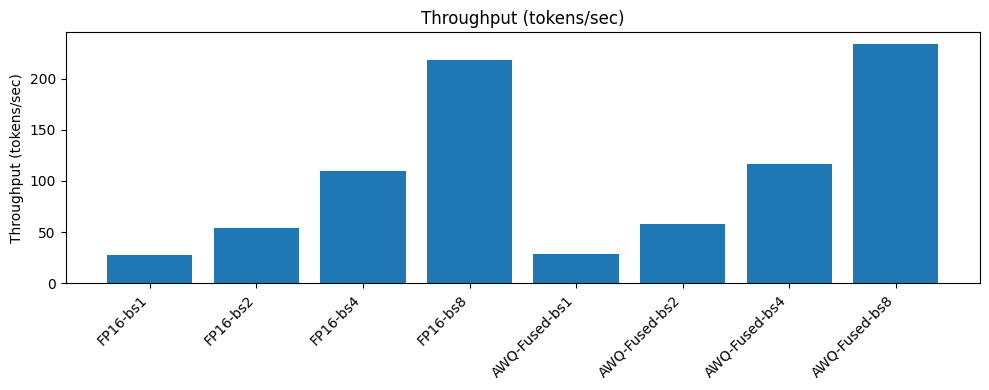

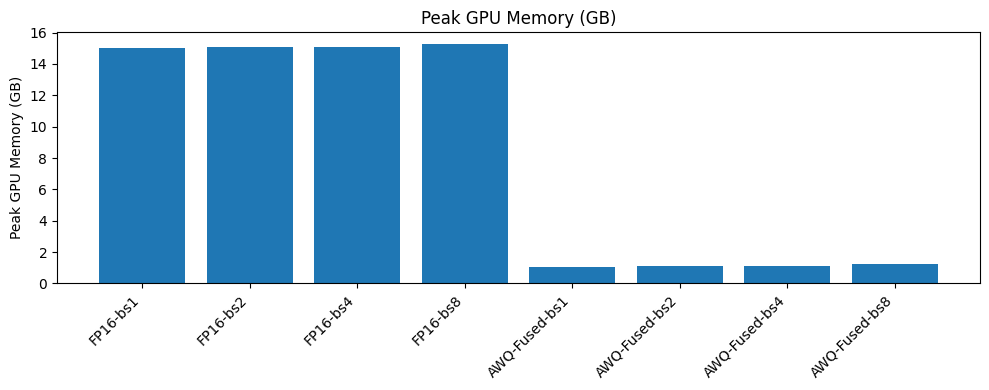

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


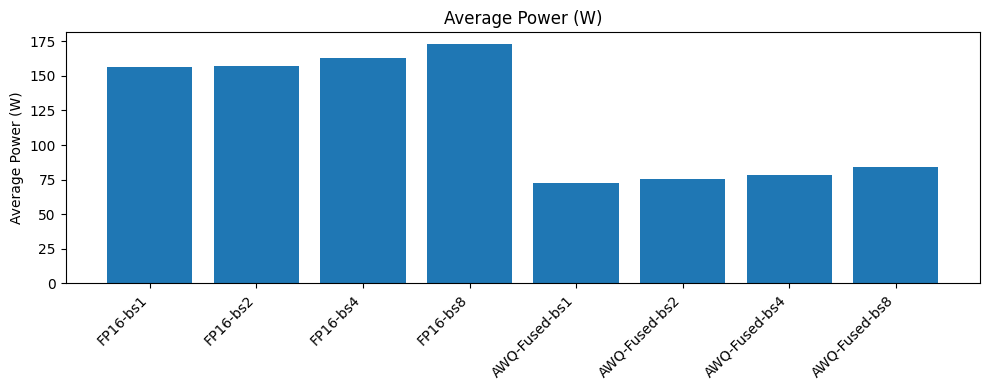

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


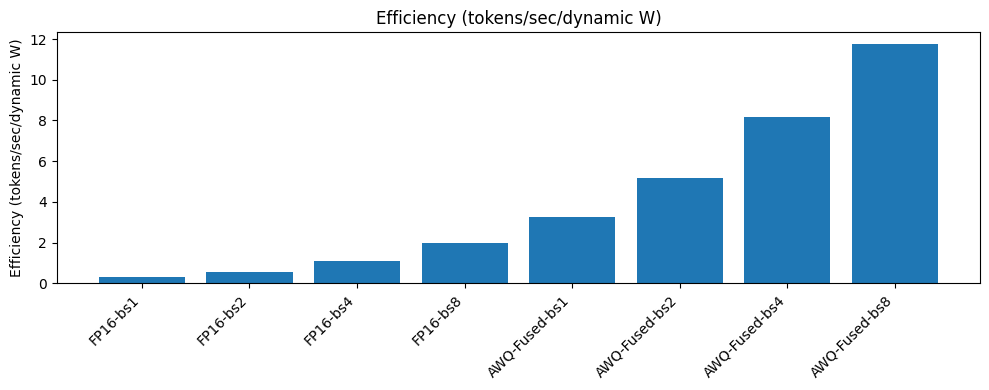

In [16]:
frames = [df_fp16, df_awq]
if not df_awq_exllama.empty:
    frames.append(df_awq_exllama)

df_all = pd.concat(frames, ignore_index=True)
display(df_all)

csv_path = "/content/awq_fp16_a100_results.csv"
df_all.to_csv(csv_path, index=False)
print("Saved:", csv_path)

plot_results(df_all)


## 11. Speedup table

This compares AWQ against FP16 at the same batch size.


In [17]:
def make_speedup_table(df):
    rows = []
    fp16_by_bs = df[df["label"] == "FP16"].set_index("batch_size")
    for _, row in df[df["label"] != "FP16"].iterrows():
        bs = row["batch_size"]
        if bs not in fp16_by_bs.index:
            continue
        base = fp16_by_bs.loc[bs]
        rows.append({
            "label": row["label"],
            "batch_size": bs,
            "throughput_speedup_vs_fp16": row["throughput_tok_s"] / base["throughput_tok_s"],
            "memory_ratio_vs_fp16": row["peak_memory_gb"] / base["peak_memory_gb"],
            "total_power_ratio_vs_fp16": row["avg_power_w"] / base["avg_power_w"],
            "dynamic_efficiency_ratio_vs_fp16": row["tok_s_per_dynamic_w"] / base["tok_s_per_dynamic_w"],
        })
    return pd.DataFrame(rows)

speedup_df = make_speedup_table(df_all)
display(speedup_df)
speedup_df.to_csv("/content/awq_fp16_a100_speedups.csv", index=False)


,label,batch_size,throughput_speedup_vs_fp16,memory_ratio_vs_fp16,total_power_ratio_vs_fp16,dynamic_efficiency_ratio_vs_fp16
0,AWQ-Fused,1,1.048836,0.070861,0.466410,10.910903
1,AWQ-Fused,2,1.069464,0.073475,0.478029,8.913807
2,AWQ-Fused,4,1.061572,0.075027,0.480205,7.369207
3,AWQ-Fused,8,1.069762,0.080469,0.485075,5.859668


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 12. PyTorch profiler check



## 13.Reload FP16 for profiler comparison



In [ ]:
!pip install -q bitsandbytes

In [20]:
from google.colab import files
files.download("/content/awq_fp16_a100_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
import pandas as pd

df_all_old = pd.read_csv("/content/awq_fp16_a100_results.csv")
display(df_all_old)

df_fp16 = df_all_old[df_all_old["label"] == "FP16"].copy()
df_awq = df_all_old[df_all_old["label"] == "AWQ-Fused"].copy()

display(df_fp16)
display(df_awq)

,label,batch_size,max_new_tokens,num_runs,warmup_runs,total_generated_tokens,total_time_s,throughput_tok_s,avg_power_w,idle_power_w,dynamic_power_w,tok_s_per_total_w,tok_s_per_dynamic_w,peak_memory_gb,avg_time_s
0,FP16,1,512,10.0,3.0,2100.0,75.756593,27.720360,156.157585,63.97194,92.185645,0.177515,0.300701,15.001884,NaN
1,FP16,2,512,10.0,3.0,4200.0,77.210016,54.397088,157.230923,63.97194,93.258983,0.345969,0.583291,15.080798,NaN
2,FP16,4,512,10.0,3.0,8400.0,76.500296,109.803497,162.892867,63.97194,98.920927,0.674084,1.110013,15.111137,NaN
3,FP16,8,512,10.0,3.0,16800.0,76.992211,218.203891,172.863100,63.97194,108.891160,1.262293,2.003871,15.256435,NaN
4,AWQ-Fused,1,512,NaN,NaN,NaN,NaN,29.074109,72.833500,63.97194,8.861560,NaN,3.280925,1.063055,17.610170
5,AWQ-Fused,2,512,NaN,NaN,NaN,NaN,58.175724,75.161000,63.97194,11.189060,NaN,5.199340,1.108063,17.601844
6,AWQ-Fused,4,512,NaN,NaN,NaN,NaN,116.564266,78.222000,63.97194,14.250060,NaN,8.179914,1.133738,17.569707
7,AWQ-Fused,8,512,NaN,NaN,NaN,NaN,233.426202,83.851500,63.97194,19.879560,NaN,11.742021,1.227667,17.547302


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,label,batch_size,max_new_tokens,num_runs,warmup_runs,total_generated_tokens,total_time_s,throughput_tok_s,avg_power_w,idle_power_w,dynamic_power_w,tok_s_per_total_w,tok_s_per_dynamic_w,peak_memory_gb,avg_time_s
0,FP16,1,512,10.0,3.0,2100.0,75.756593,27.720360,156.157585,63.97194,92.185645,0.177515,0.300701,15.001884,NaN
1,FP16,2,512,10.0,3.0,4200.0,77.210016,54.397088,157.230923,63.97194,93.258983,0.345969,0.583291,15.080798,NaN
2,FP16,4,512,10.0,3.0,8400.0,76.500296,109.803497,162.892867,63.97194,98.920927,0.674084,1.110013,15.111137,NaN
3,FP16,8,512,10.0,3.0,16800.0,76.992211,218.203891,172.863100,63.97194,108.891160,1.262293,2.003871,15.256435,NaN


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,label,batch_size,max_new_tokens,num_runs,warmup_runs,total_generated_tokens,total_time_s,throughput_tok_s,avg_power_w,idle_power_w,dynamic_power_w,tok_s_per_total_w,tok_s_per_dynamic_w,peak_memory_gb,avg_time_s
4,AWQ-Fused,1,512,NaN,NaN,NaN,NaN,29.074109,72.8335,63.97194,8.86156,NaN,3.280925,1.063055,17.610170
5,AWQ-Fused,2,512,NaN,NaN,NaN,NaN,58.175724,75.1610,63.97194,11.18906,NaN,5.199340,1.108063,17.601844
6,AWQ-Fused,4,512,NaN,NaN,NaN,NaN,116.564266,78.2220,63.97194,14.25006,NaN,8.179914,1.133738,17.569707
7,AWQ-Fused,8,512,NaN,NaN,NaN,NaN,233.426202,83.8515,63.97194,19.87956,NaN,11.742021,1.227667,17.547302


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [23]:
print("df_fp16 exists:", "df_fp16" in globals())
print("df_awq exists:", "df_awq" in globals())
print("model_fp16 exists:", "model_fp16" in globals())
print("model_awq exists:", "model_awq" in globals())
print("model_int8 exists:", "model_int8" in globals())
print("df_int8 exists:", "df_int8" in globals())

df_fp16 exists: True
df_awq exists: True
model_fp16 exists: True
model_awq exists: True
model_int8 exists: False
df_int8 exists: False


In [24]:
import pandas as pd

df_awq_fp16_saved = pd.concat([df_fp16, df_awq], ignore_index=True)

csv_path = "/content/awq_fp16_a100_results_backup.csv"
df_awq_fp16_saved.to_csv(csv_path, index=False)

print("Saved backup:", csv_path)
display(df_awq_fp16_saved)

Saved backup: /content/awq_fp16_a100_results_backup.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,label,batch_size,max_new_tokens,num_runs,warmup_runs,total_generated_tokens,total_time_s,throughput_tok_s,avg_power_w,idle_power_w,dynamic_power_w,tok_s_per_total_w,tok_s_per_dynamic_w,peak_memory_gb,avg_time_s
0,FP16,1,512,10.0,3.0,2100.0,75.756593,27.720360,156.157585,63.97194,92.185645,0.177515,0.300701,15.001884,NaN
1,FP16,2,512,10.0,3.0,4200.0,77.210016,54.397088,157.230923,63.97194,93.258983,0.345969,0.583291,15.080798,NaN
2,FP16,4,512,10.0,3.0,8400.0,76.500296,109.803497,162.892867,63.97194,98.920927,0.674084,1.110013,15.111137,NaN
3,FP16,8,512,10.0,3.0,16800.0,76.992211,218.203891,172.863100,63.97194,108.891160,1.262293,2.003871,15.256435,NaN
4,AWQ-Fused,1,512,NaN,NaN,NaN,NaN,29.074109,72.833500,63.97194,8.861560,NaN,3.280925,1.063055,17.610170
5,AWQ-Fused,2,512,NaN,NaN,NaN,NaN,58.175724,75.161000,63.97194,11.189060,NaN,5.199340,1.108063,17.601844
6,AWQ-Fused,4,512,NaN,NaN,NaN,NaN,116.564266,78.222000,63.97194,14.250060,NaN,8.179914,1.133738,17.569707
7,AWQ-Fused,8,512,NaN,NaN,NaN,NaN,233.426202,83.851500,63.97194,19.879560,NaN,11.742021,1.227667,17.547302


## INT8 bitsandbytes model



In [27]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch
import pandas as pd

BASE_MODEL = "meta-llama/Meta-Llama-3.1-8B-Instruct"

clear_gpu()

tokenizer_int8 = AutoTokenizer.from_pretrained(
    BASE_MODEL,
    trust_remote_code=True,
    token=True,
)

if tokenizer_int8.pad_token is None:
    tokenizer_int8.pad_token = tokenizer_int8.eos_token

tokenizer_int8.padding_side = "left"

bnb_config_int8 = BitsAndBytesConfig(
    load_in_8bit=True,
)

model_int8 = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config_int8,
    device_map={"": 0},
    trust_remote_code=True,
    token=True,
)

model_int8.eval()

print("INT8 bitsandbytes model loaded successfully")
print_module_summary(model_int8, title="INT8 module summary")
print("INT8 device:", get_model_device(model_int8))

/usr/local/lib/python3.12/dist-packages/torch/jit/_script.py:365: DeprecationWarning: `torch.jit.script_method` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

INT8 bitsandbytes model loaded successfully

INT8 module summary
-------------------
Linear8bitLt: 224
LlamaRMSNorm: 65
LlamaDecoderLayer: 32
LlamaAttention: 32
LlamaMLP: 32
SiLU: 32
LlamaForCausalLM: 1
LlamaModel: 1
Embedding: 1
ModuleList: 1
LlamaRotaryEmbedding: 1
Linear: 1
INT8 device: cuda:0


In [28]:
# Benchmark settings
BATCH_SIZES = [1, 2, 4, 8]
MAX_NEW_TOKENS = 512
WARMUP_RUNS = 3
NUM_RUNS = 10

if "idle_power_w" not in globals():
    idle_power_w = 48.961194

print("BATCH_SIZES:", BATCH_SIZES)
print("MAX_NEW_TOKENS:", MAX_NEW_TOKENS)
print("WARMUP_RUNS:", WARMUP_RUNS)
print("NUM_RUNS:", NUM_RUNS)
print("idle_power_w:", idle_power_w)

BATCH_SIZES: [1, 2, 4, 8]
MAX_NEW_TOKENS: 512
WARMUP_RUNS: 3
NUM_RUNS: 10
idle_power_w: 63.97194029850745


In [29]:
int8_results = []

for bs in BATCH_SIZES:
    try:
        result = benchmark_generate(
            model_int8,
            tokenizer_int8,
            "BNB-INT8",
            batch_size=bs,
            idle_power_w=idle_power_w
        )
        int8_results.append(result)

    except torch.cuda.OutOfMemoryError:
        print(f"OOM for INT8 batch size {bs}. Skipping.")
        clear_gpu()

df_int8 = pd.DataFrame(int8_results)
display(df_int8)

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:636: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:6

,label,batch_size,max_new_tokens,avg_time_s,throughput_tok_s,avg_power_w,idle_power_w,dynamic_power_w,tok_s_per_dynamic_w,peak_memory_gb
0,BNB-INT8,1,512,83.332753,6.144043,71.8815,63.97194,7.90956,0.776787,26.310141
1,BNB-INT8,2,512,92.671901,11.049736,74.0280,63.97194,10.05606,1.098814,26.355817
2,BNB-INT8,4,512,92.769569,22.076205,76.1870,63.97194,12.21506,1.807294,26.522226
3,BNB-INT8,8,512,92.469257,44.295803,76.4910,63.97194,12.51906,3.538269,26.853930


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [30]:
df_all = pd.concat([df_fp16, df_int8, df_awq], ignore_index=True)
display(df_all)

csv_path = "/content/fp16_int8_awq_a100_results.csv"
df_all.to_csv(csv_path, index=False)

print("Saved:", csv_path)

,label,batch_size,max_new_tokens,num_runs,warmup_runs,total_generated_tokens,total_time_s,throughput_tok_s,avg_power_w,idle_power_w,dynamic_power_w,tok_s_per_total_w,tok_s_per_dynamic_w,peak_memory_gb,avg_time_s
0,FP16,1,512,10.0,3.0,2100.0,75.756593,27.720360,156.157585,63.97194,92.185645,0.177515,0.300701,15.001884,NaN
1,FP16,2,512,10.0,3.0,4200.0,77.210016,54.397088,157.230923,63.97194,93.258983,0.345969,0.583291,15.080798,NaN
2,FP16,4,512,10.0,3.0,8400.0,76.500296,109.803497,162.892867,63.97194,98.920927,0.674084,1.110013,15.111137,NaN
3,FP16,8,512,10.0,3.0,16800.0,76.992211,218.203891,172.863100,63.97194,108.891160,1.262293,2.003871,15.256435,NaN
4,BNB-INT8,1,512,NaN,NaN,NaN,NaN,6.144043,71.881500,63.97194,7.909560,NaN,0.776787,26.310141,83.332753
5,BNB-INT8,2,512,NaN,NaN,NaN,NaN,11.049736,74.028000,63.97194,10.056060,NaN,1.098814,26.355817,92.671901
6,BNB-INT8,4,512,NaN,NaN,NaN,NaN,22.076205,76.187000,63.97194,12.215060,NaN,1.807294,26.522226,92.769569
7,BNB-INT8,8,512,NaN,NaN,NaN,NaN,44.295803,76.491000,63.97194,12.519060,NaN,3.538269,26.853930,92.469257
8,AWQ-Fused,1,512,NaN,NaN,NaN,NaN,29.074109,72.833500,63.97194,8.861560,NaN,3.280925,1.063055,17.610170
9,AWQ-Fused,2,512,NaN,NaN,NaN,NaN,58.175724,75.161000,63.97194,11.189060,NaN,5.199340,1.108063,17.601844


Saved: /content/fp16_int8_awq_a100_results.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [31]:
df_plot = df_all.copy()

label_map = {
    "FP16": "FP16",
    "BNB-INT8": "INT8",
    "AWQ-Fused": "AWQ-INT4"
}

df_plot["method"] = df_plot["label"].map(label_map).fillna(df_plot["label"])
df_plot["batch_size"] = df_plot["batch_size"].astype(int)

display(df_plot[[
    "method",
    "batch_size",
    "throughput_tok_s",
    "avg_power_w",
    "dynamic_power_w",
    "tok_s_per_dynamic_w",
    "peak_memory_gb"
]])

,method,batch_size,throughput_tok_s,avg_power_w,dynamic_power_w,tok_s_per_dynamic_w,peak_memory_gb
0,FP16,1,27.720360,156.157585,92.185645,0.300701,15.001884
1,FP16,2,54.397088,157.230923,93.258983,0.583291,15.080798
2,FP16,4,109.803497,162.892867,98.920927,1.110013,15.111137
3,FP16,8,218.203891,172.863100,108.891160,2.003871,15.256435
4,INT8,1,6.144043,71.881500,7.909560,0.776787,26.310141
5,INT8,2,11.049736,74.028000,10.056060,1.098814,26.355817
6,INT8,4,22.076205,76.187000,12.215060,1.807294,26.522226
7,INT8,8,44.295803,76.491000,12.519060,3.538269,26.853930
8,AWQ-INT4,1,29.074109,72.833500,8.861560,3.280925,1.063055
9,AWQ-INT4,2,58.175724,75.161000,11.189060,5.199340,1.108063


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [32]:
def grouped_bar_plot(df, metric, ylabel, title, filename):
    methods = ["FP16", "INT8", "AWQ-INT4"]
    batch_sizes = sorted(df["batch_size"].unique())

    x = np.arange(len(batch_sizes))
    width = 0.25

    plt.figure(figsize=(8, 5))

    for i, method in enumerate(methods):
        values = []
        for bs in batch_sizes:
            row = df[(df["method"] == method) & (df["batch_size"] == bs)]
            if row.empty:
                values.append(np.nan)
            else:
                values.append(row[metric].iloc[0])

        plt.bar(x + (i - 1) * width, values, width, label=method)

    plt.xlabel("Batch size")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(x, batch_sizes)
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", filename)

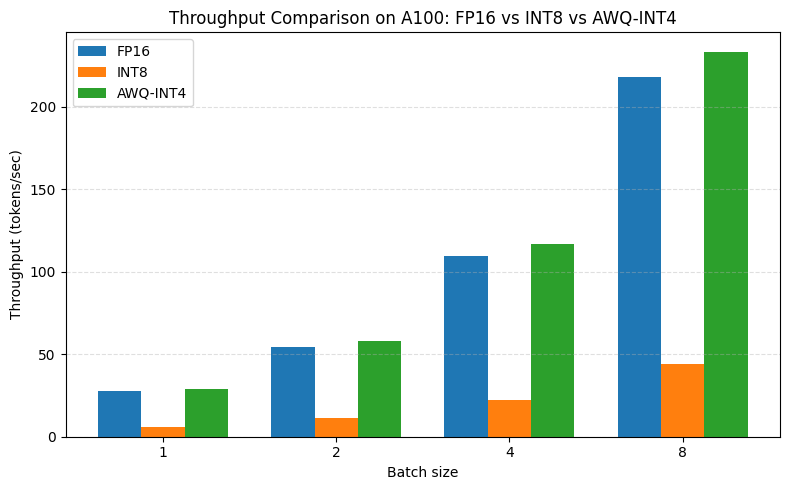

Saved: /content/throughput_comparison.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [33]:
grouped_bar_plot(
    df_plot,
    metric="throughput_tok_s",
    ylabel="Throughput (tokens/sec)",
    title="Throughput Comparison on A100: FP16 vs INT8 vs AWQ-INT4",
    filename="/content/throughput_comparison.png"
)

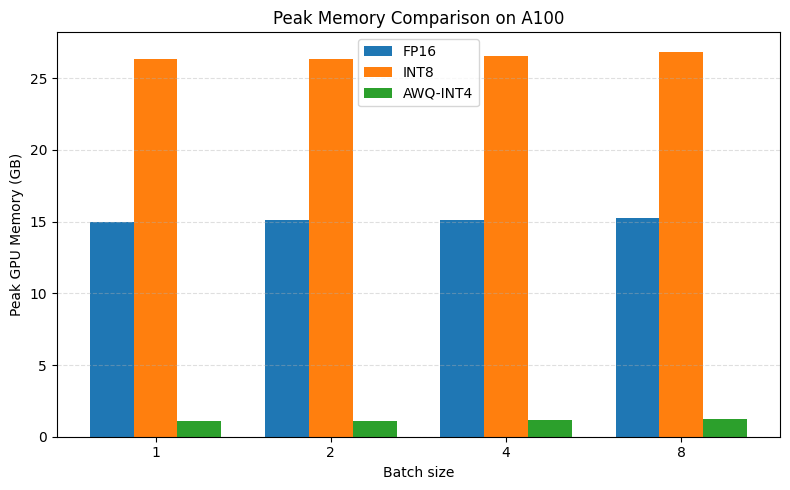

Saved: /content/memory_comparison.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [34]:
grouped_bar_plot(
    df_plot,
    metric="peak_memory_gb",
    ylabel="Peak GPU Memory (GB)",
    title="Peak Memory Comparison on A100",
    filename="/content/memory_comparison.png"
)

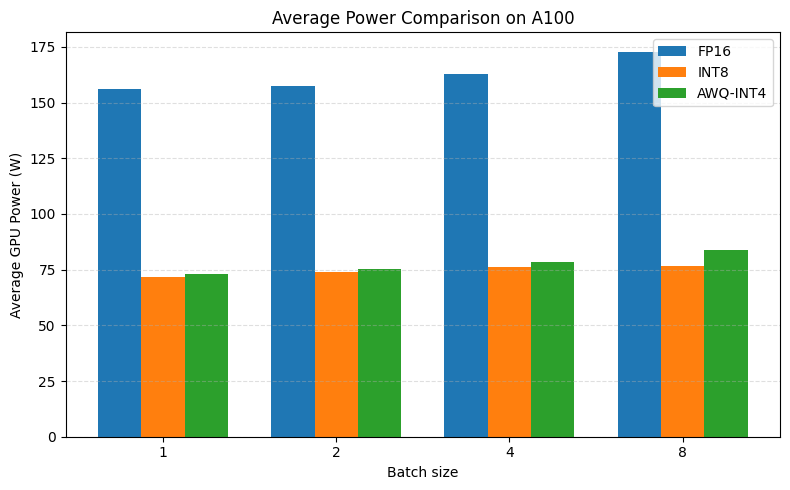

Saved: /content/power_comparison.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [35]:
grouped_bar_plot(
    df_plot,
    metric="avg_power_w",
    ylabel="Average GPU Power (W)",
    title="Average Power Comparison on A100",
    filename="/content/power_comparison.png"
)

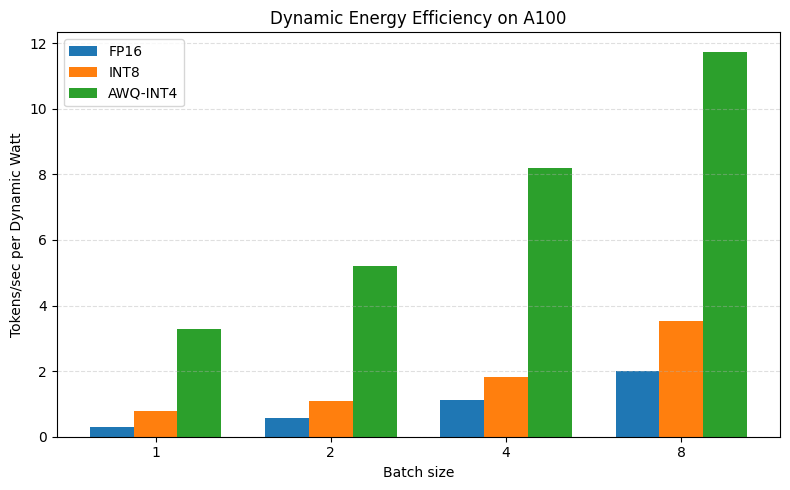

Saved: /content/dynamic_efficiency_comparison.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [36]:
grouped_bar_plot(
    df_plot,
    metric="tok_s_per_dynamic_w",
    ylabel="Tokens/sec per Dynamic Watt",
    title="Dynamic Energy Efficiency on A100",
    filename="/content/dynamic_efficiency_comparison.png"
)

In [37]:
rows = []

for bs in sorted(df_plot["batch_size"].unique()):
    fp16 = df_plot[(df_plot["method"] == "FP16") & (df_plot["batch_size"] == bs)].iloc[0]

    for method in ["INT8", "AWQ-INT4"]:
        row = df_plot[(df_plot["method"] == method) & (df_plot["batch_size"] == bs)]

        if row.empty:
            continue

        row = row.iloc[0]

        rows.append({
            "method": method,
            "batch_size": bs,
            "throughput_speedup_vs_fp16": row["throughput_tok_s"] / fp16["throughput_tok_s"],
            "memory_ratio_vs_fp16": row["peak_memory_gb"] / fp16["peak_memory_gb"],
            "power_ratio_vs_fp16": row["avg_power_w"] / fp16["avg_power_w"],
            "dynamic_efficiency_ratio_vs_fp16": row["tok_s_per_dynamic_w"] / fp16["tok_s_per_dynamic_w"],
        })

df_speedup = pd.DataFrame(rows)
display(df_speedup)

df_speedup.to_csv("/content/fp16_int8_awq_speedup_ratios.csv", index=False)
print("Saved: /content/fp16_int8_awq_speedup_ratios.csv")

,method,batch_size,throughput_speedup_vs_fp16,memory_ratio_vs_fp16,power_ratio_vs_fp16,dynamic_efficiency_ratio_vs_fp16
0,INT8,1,0.221644,1.753789,0.460314,2.583250
1,AWQ-INT4,1,1.048836,0.070861,0.466410,10.910903
2,INT8,2,0.203131,1.747641,0.470823,1.883819
3,AWQ-INT4,2,1.069464,0.073475,0.478029,8.913807
4,INT8,4,0.201052,1.755144,0.467712,1.628174
5,AWQ-INT4,4,1.061572,0.075027,0.480205,7.369207
6,INT8,8,0.203002,1.760171,0.442495,1.765717
7,AWQ-INT4,8,1.069762,0.080469,0.485075,5.859668


Saved: /content/fp16_int8_awq_speedup_ratios.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


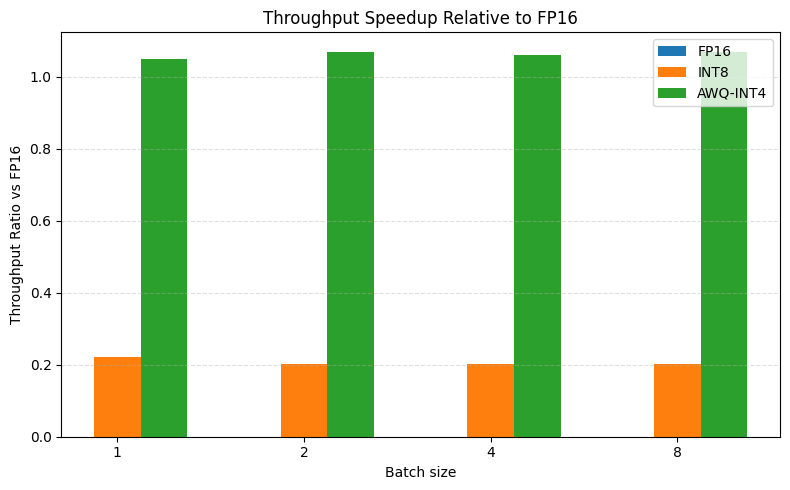

Saved: /content/throughput_speedup_vs_fp16.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [38]:
grouped_bar_plot(
    df_speedup,
    metric="throughput_speedup_vs_fp16",
    ylabel="Throughput Ratio vs FP16",
    title="Throughput Speedup Relative to FP16",
    filename="/content/throughput_speedup_vs_fp16.png"
)

In [39]:
from google.colab import files

for f in [
    "/content/throughput_comparison.png",
    "/content/memory_comparison.png",
    "/content/power_comparison.png",
    "/content/dynamic_efficiency_comparison.png",
    "/content/throughput_speedup_vs_fp16.png",
    "/content/fp16_int8_awq_speedup_ratios.csv",
]:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###  Perplexity / quality evaluation

In [3]:
!pip install -q datasets

import math, gc
import torch
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from awq import AutoAWQForCausalLM

BASE_MODEL    = "meta-llama/Meta-Llama-3.1-8B-Instruct"
AWQ_MODEL_8B  = "hugging-quants/Meta-Llama-3.1-8B-Instruct-AWQ-INT4"  # 8B, matches FP16/INT8
PPL_MAX_LENGTH = 2048      # context window
PPL_STRIDE     = 512       # sliding-window stride
MAX_EVAL_TOKENS = None     # None = full WikiText-2 test set; set e.g. 50000 for a quick smoke test

wikitext_test = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
wikitext_text = "\n\n".join(wikitext_test["text"])
print("Loaded WikiText-2 test set, ~%d characters" % len(wikitext_text))

def get_lm_forward(model):
    inner = getattr(model, "model", None)
    if "awq" in type(model).__name__.lower() and inner is not None and hasattr(inner, "lm_head"):
        return inner
    return model

@torch.inference_mode()
def compute_perplexity(model, tokenizer, text, max_length=2048, stride=512, max_eval_tokens=None):
    device = get_model_device(model)          # reuses your existing helper
    fwd = get_lm_forward(model)

    enc = tokenizer(text, return_tensors="pt")
    input_ids_full = enc.input_ids
    if max_eval_tokens is not None:
        input_ids_full = input_ids_full[:, :max_eval_tokens]
    seq_len = input_ids_full.size(1)

    loss_fct = torch.nn.CrossEntropyLoss(reduction="sum", ignore_index=-100)
    nll_sum, n_tokens, prev_end = 0.0, 0, 0

    for begin in range(0, seq_len, stride):
        end = min(begin + max_length, seq_len)
        trg_len = end - prev_end                       # only score the new (non-overlapping) tokens
        input_ids = input_ids_full[:, begin:end].to(device)
        target_ids = input_ids.clone()
        target_ids[:, :-trg_len] = -100                # mask the overlap region

        logits = fwd(input_ids=input_ids).logits
        shift_logits = logits[:, :-1, :].contiguous()
        shift_labels = target_ids[:, 1:].contiguous()

        valid = (shift_labels != -100)
        if valid.any():
            loss = loss_fct(shift_logits.view(-1, shift_logits.size(-1)).float(),
                            shift_labels.view(-1))
            nll_sum += loss.item()
            n_tokens += int(valid.sum().item())

        prev_end = end
        if end == seq_len:
            break

    return {"perplexity": math.exp(nll_sum / n_tokens),
            "nll_per_token": nll_sum / n_tokens,
            "eval_tokens": n_tokens}

ppl_results = {}

def run_ppl(label, load_fn):
    clear_gpu()
    print(f"\n=== Loading {label} ===")
    model, tok = load_fn()
    model.eval()
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    print(f"Computing WikiText-2 perplexity for {label} ...")
    res = compute_perplexity(model, tok, wikitext_text,
                             max_length=PPL_MAX_LENGTH, stride=PPL_STRIDE,
                             max_eval_tokens=MAX_EVAL_TOKENS)
    res["label"] = label
    ppl_results[label] = res
    print(f"{label}: perplexity = {res['perplexity']:.4f}  (eval_tokens={res['eval_tokens']})")
    del model
    gc.collect(); clear_gpu()
    return res

/usr/local/lib/python3.12/dist-packages/awq/__init__.py:21: DeprecationWarning: 
I have left this message as the final dev message to help you transition.

Important Notice:
- AutoAWQ is officially deprecated and will no longer be maintained.
- The last tested configuration used Torch 2.6.0 and Transformers 4.51.3.
- If future versions of Transformers break AutoAWQ compatibility, please report the issue to the Transformers project.

Alternative:
- AutoAWQ has been adopted by the vLLM Project: https://github.com/vllm-project/llm-compressor

For further inquiries, feel free to reach out:
- X: https://x.com/casper_hansen_
- LinkedIn: https://www.linkedin.com/in/casper-hansen-804005170/

  warnings.warn(_FINAL_DEV_MESSAGE, category=DeprecationWarning, stacklevel=1)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes

Loaded WikiText-2 test set, ~1294336 characters


### Load FP16

In [4]:
import gc
import time
import math
import torch
import pandas as pd

def clear_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

def get_gpu_memory_gb():
    if not torch.cuda.is_available():
        return float("nan")
    torch.cuda.synchronize()
    return torch.cuda.max_memory_allocated() / 1024**3


In [5]:
import gc
import time
import math
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM

def clear_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

def get_model_device(model):
    """
    Robustly find which device the model is on.
    Works for normal HF models and some quantized/wrapped models.
    """
    try:
        return model.device
    except Exception:
        pass

    try:
        return next(model.parameters()).device
    except Exception:
        pass

    try:
        return next(model.buffers()).device
    except Exception:
        pass

    return torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def get_lm_forward(model):
    """
    Handles normal models and some wrapped/quantized models.
    Usually this just returns model.forward.
    """
    if hasattr(model, "forward"):
        return model.forward
    if hasattr(model, "model") and hasattr(model.model, "forward"):
        return model.model.forward
    raise AttributeError("Could not find a forward method for this model.")

def get_gpu_memory_gb():
    if not torch.cuda.is_available():
        return float("nan")
    torch.cuda.synchronize()
    return torch.cuda.max_memory_allocated() / 1024**3

In [6]:
def load_fp16():
    tok = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True, token=True)
    m = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL, torch_dtype=torch.float16,
        device_map={"": 0}, trust_remote_code=True, token=True)
    return m, tok

run_ppl("FP16", load_fp16)


=== Loading FP16 ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Computing WikiText-2 perplexity for FP16 ...


Token indices sequence length is longer than the specified maximum sequence length for this model (289077 > 131072). Running this sequence through the model will result in indexing errors


FP16: perplexity = 6.4252  (eval_tokens=289076)


{'perplexity': 6.425156720485768,
 'nll_per_token': 1.860221022777301,
 'eval_tokens': 289076,
 'label': 'FP16'}

### Load Int8

In [7]:
def load_int8():
    tok = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True, token=True)
    bnb = BitsAndBytesConfig(load_in_8bit=True)
    m = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL, quantization_config=bnb,
        device_map={"": 0}, trust_remote_code=True, token=True)
    return m, tok

run_ppl("INT8", load_int8)


=== Loading INT8 ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Computing WikiText-2 perplexity for INT8 ...


Token indices sequence length is longer than the specified maximum sequence length for this model (289077 > 131072). Running this sequence through the model will result in indexing errors


INT8: perplexity = 6.4866  (eval_tokens=289076)


{'perplexity': 6.4866444795208595,
 'nll_per_token': 1.8697453676605995,
 'eval_tokens': 289076,
 'label': 'INT8'}

### Load AWQ-INT4

In [8]:
def load_awq():
    tok = AutoTokenizer.from_pretrained(AWQ_MODEL_8B, trust_remote_code=True, token=True)
    m = AutoAWQForCausalLM.from_quantized(
        AWQ_MODEL_8B, fuse_layers=False,        # non-fused for the accuracy eval
        trust_remote_code=True, safetensors=True, device_map={"": 0})
    return m, tok

run_ppl("AWQ-INT4", load_awq)


=== Loading AWQ-INT4 ===


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Replacing layers...: 100%|██████████| 32/32 [00:13<00:00,  2.33it/s]


Computing WikiText-2 perplexity for AWQ-INT4 ...


Token indices sequence length is longer than the specified maximum sequence length for this model (289077 > 131072). Running this sequence through the model will result in indexing errors


AWQ-INT4: perplexity = 6.7370  (eval_tokens=289076)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


{'perplexity': 6.737012845168671,
 'nll_per_token': 1.9076166286367424,
 'eval_tokens': 289076,
 'label': 'AWQ-INT4'}

### Table + Plot + save

,label,perplexity,nll_per_token,eval_tokens,ppl_increase_vs_fp16_%
0,FP16,6.425157,1.860221,289076,0.000000
1,INT8,6.486644,1.869745,289076,0.956985
2,AWQ-INT4,6.737013,1.907617,289076,4.853673


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


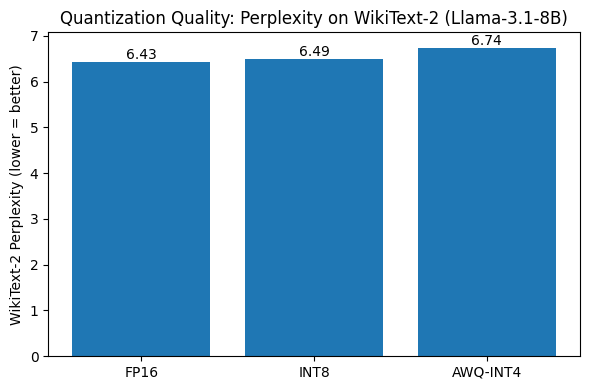

In [9]:
order = ["FP16", "INT8", "AWQ-INT4"]
ppl_df = pd.DataFrame([ppl_results[k] for k in order if k in ppl_results])
ppl_df = ppl_df[["label", "perplexity", "nll_per_token", "eval_tokens"]]

# degradation relative to FP16
if "FP16" in ppl_results:
    base = ppl_results["FP16"]["perplexity"]
    ppl_df["ppl_increase_vs_fp16_%"] = (ppl_df["perplexity"] / base - 1) * 100

display(ppl_df)
ppl_df.to_csv("/content/wikitext2_perplexity.csv", index=False)

plt.figure(figsize=(6, 4))
bars = plt.bar(ppl_df["label"], ppl_df["perplexity"])
plt.ylabel("WikiText-2 Perplexity (lower = better)")
plt.title("Quantization Quality: Perplexity on WikiText-2 (Llama-3.1-8B)")
for b, v in zip(bars, ppl_df["perplexity"]):
    plt.text(b.get_x() + b.get_width()/2, v, f"{v:.2f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig("/content/wikitext2_perplexity.png", dpi=300, bbox_inches="tight")
plt.show()

### KV benchmark helper

In [10]:
!pip install -q optimum-quanto hqq

import time, gc, math
import torch, pandas as pd, matplotlib.pyplot as plt

def make_long_inputs(tokenizer, target_prompt_tokens, batch_size, device):
    ids = tokenizer(wikitext_text, return_tensors="pt").input_ids[0]
    if ids.size(0) < target_prompt_tokens:
        ids = ids.repeat((target_prompt_tokens // ids.size(0)) + 1)
    ids = ids[:target_prompt_tokens].unsqueeze(0).repeat(batch_size, 1)
    return {"input_ids": ids.to(device),
            "attention_mask": torch.ones_like(ids).to(device)}

@torch.inference_mode()
def bench_kv(model, tokenizer, label, cache_config=None,
             batch_size=4, prompt_tokens=2048, max_new_tokens=512,
             warmup=2, runs=5):
    clear_gpu()
    device = get_model_device(model)
    inputs = make_long_inputs(tokenizer, prompt_tokens, batch_size, device)

    gen_kwargs = dict(max_new_tokens=max_new_tokens, do_sample=False,
                      use_cache=True, pad_token_id=tokenizer.eos_token_id)
    if cache_config is not None:
        gen_kwargs["cache_implementation"] = "quantized"
        gen_kwargs["cache_config"] = cache_config

    for _ in range(warmup):
        _ = model.generate(**inputs, **gen_kwargs); torch.cuda.synchronize()

    clear_gpu()
    times = []
    for _ in range(runs):
        torch.cuda.synchronize(); t0 = time.perf_counter()
        out = model.generate(**inputs, **gen_kwargs)
        torch.cuda.synchronize(); times.append(time.perf_counter() - t0)

    new_tokens = (out.shape[1] - inputs["input_ids"].shape[1]) * batch_size
    avg_time = sum(times) / len(times)
    return {"label": label, "batch_size": batch_size,
            "prompt_tokens": prompt_tokens, "max_new_tokens": max_new_tokens,
            "throughput_tok_s": new_tokens / avg_time,
            "peak_memory_gb": torch.cuda.max_memory_allocated() / 1024**3}

### Run the three KV-cache modes

In [11]:
if "model_fp16" not in globals() or globals().get("model_fp16") is None:
    model_fp16, tokenizer_fp16 = load_fp16(); model_fp16.eval()

# KV-cache configs
kv_cfgs = [
    ("KV-FP16 baseline", None),

    ("KV-INT4 quanto", {
        "backend": "quanto",
        "nbits": 4,
        "axis_key": 0,
        "axis_value": 0,
    }),

    ("KV-INT8 hqq", {
        "backend": "hqq",
        "nbits": 8,
        "axis_key": 1,
        "axis_value": 1,
    }),
]

kv_results = []
for label, cfg in kv_cfgs:
    try:
        r = bench_kv(model_fp16, tokenizer_fp16, label, cache_config=cfg,
                     batch_size=4, prompt_tokens=2048, max_new_tokens=512)
        kv_results.append(r); print(r)
    except Exception as e:
        print(f"{label} FAILED: {type(e).__name__}: {str(e)[:300]}")
        clear_gpu()

df_kv = pd.DataFrame(kv_results)
display(df_kv)
df_kv.to_csv("/content/kv_cache_quant_results.csv", index=False)

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (289077 > 131072). Running this sequence through the model will result in indexing errors
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:636: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


{'label': 'KV-FP16 baseline', 'batch_size': 4, 'prompt_tokens': 2048, 'max_new_tokens': 512, 'throughput_tok_s': 105.2745791444328, 'peak_memory_gb': 16.875956058502197}


/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:636: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


{'label': 'KV-INT4 quanto', 'batch_size': 4, 'prompt_tokens': 2048, 'max_new_tokens': 512, 'throughput_tok_s': 79.4431452901994, 'peak_memory_gb': 16.157206058502197}
KV-INT8 hqq FAILED: KeyError: 'hqq'


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,label,batch_size,prompt_tokens,max_new_tokens,throughput_tok_s,peak_memory_gb
0,KV-FP16 baseline,4,2048,512,105.274579,16.875956
1,KV-INT4 quanto,4,2048,512,79.443145,16.157206


### Context-length sweep

 ### Quality Check
 Since perplexity won't show KV-quant quality, a same-prompt greedy comparison is the simplest check that the quantized cache isn't degrading outputs:

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:636: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


KV-FP16 baseline @ 512: 15.44 GB, 107.5 tok/s
KV-INT4 quanto @ 512: 15.26 GB, 81.2 tok/s
KV-INT8 hqq @ 512 failed: 'hqq'
KV-FP16 baseline @ 1024: 15.92 GB, 102.7 tok/s
KV-INT4 quanto @ 1024: 15.56 GB, 77.9 tok/s
KV-INT8 hqq @ 1024 failed: 'hqq'
KV-FP16 baseline @ 2048: 16.88 GB, 102.4 tok/s
KV-INT4 quanto @ 2048: 16.16 GB, 77.6 tok/s
KV-INT8 hqq @ 2048 failed: 'hqq'
KV-FP16 baseline @ 4096: 18.79 GB, 87.7 tok/s
KV-INT4 quanto @ 4096: 17.35 GB, 65.6 tok/s
KV-INT8 hqq @ 4096 failed: 'hqq'
KV-FP16 baseline @ 8192: 22.61 GB, 54.5 tok/s
KV-INT4 quanto @ 8192: 19.73 GB, 38.9 tok/s
KV-INT8 hqq @ 8192 failed: 'hqq'


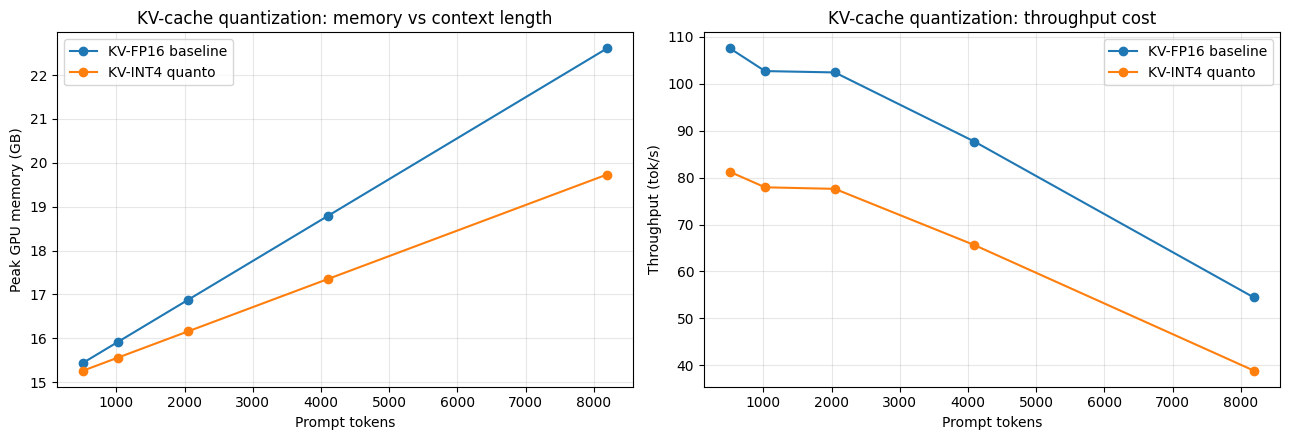

In [12]:
sweep_rows = []
for ptok in [512, 1024, 2048, 4096, 8192]:
    for label, cfg in kv_cfgs:
        try:
            r = bench_kv(model_fp16, tokenizer_fp16, f"{label}", cache_config=cfg,
                         batch_size=4, prompt_tokens=ptok, max_new_tokens=256,
                         warmup=1, runs=3)
            sweep_rows.append(r); print(f"{label} @ {ptok}: "
                  f"{r['peak_memory_gb']:.2f} GB, {r['throughput_tok_s']:.1f} tok/s")
        except Exception as e:
            print(f"{label} @ {ptok} failed: {str(e)[:150]}"); clear_gpu()

df_kv_sweep = pd.DataFrame(sweep_rows)
df_kv_sweep.to_csv("/content/kv_cache_sweep.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for label in df_kv_sweep["label"].unique():
    d = df_kv_sweep[df_kv_sweep["label"] == label]
    axes[0].plot(d["prompt_tokens"], d["peak_memory_gb"], marker="o", label=label)
    axes[1].plot(d["prompt_tokens"], d["throughput_tok_s"], marker="o", label=label)
axes[0].set(xlabel="Prompt tokens", ylabel="Peak GPU memory (GB)",
            title="KV-cache quantization: memory vs context length")
axes[1].set(xlabel="Prompt tokens", ylabel="Throughput (tok/s)",
            title="KV-cache quantization: throughput cost")
for ax in axes: ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("/content/kv_cache_sweep.png", dpi=300, bbox_inches="tight"); plt.show()

In [13]:
msgs = [{"role": "user", "content": "Explain algorithm-hardware co-design for efficient LLM inference."}]
text = tokenizer_fp16.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
enc = tokenizer_fp16(text, return_tensors="pt").to(get_model_device(model_fp16))
n = enc.input_ids.shape[1]

base = model_fp16.generate(**enc, max_new_tokens=200, do_sample=False)
int4 = model_fp16.generate(**enc, max_new_tokens=200, do_sample=False,
                           cache_implementation="quantized",
                           cache_config={"backend": "quanto", "nbits": 4})
print("=== FP16 KV ===\n", tokenizer_fp16.decode(base[0][n:], skip_special_tokens=True))
print("\n=== INT4 KV ===\n", tokenizer_fp16.decode(int4[0][n:], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


=== FP16 KV ===
 Algorithm-hardware co-design is a crucial aspect of developing efficient Large Language Models (LLMs) for inference. It involves designing both the algorithm and the hardware architecture simultaneously to optimize the performance, power consumption, and area of the system. Here's a comprehensive overview of the algorithm-hardware co-design for efficient LLM inference:

**Why Co-design is necessary:**

1.  **Computational complexity:** LLMs require massive computational resources to process and generate text, which can be a significant challenge for real-time inference.
2.  **Power consumption:** LLMs are computationally intensive, leading to high power consumption, which can be a concern for battery-powered devices or data centers.
3.  **Area efficiency:** LLMs require significant memory and processing resources, making them challenging to implement in hardware.

**Algorithm-hardware co-design for LLM inference:**

1.  **Model pruning and quantization:** Prune and qua

### Pareto summary plot

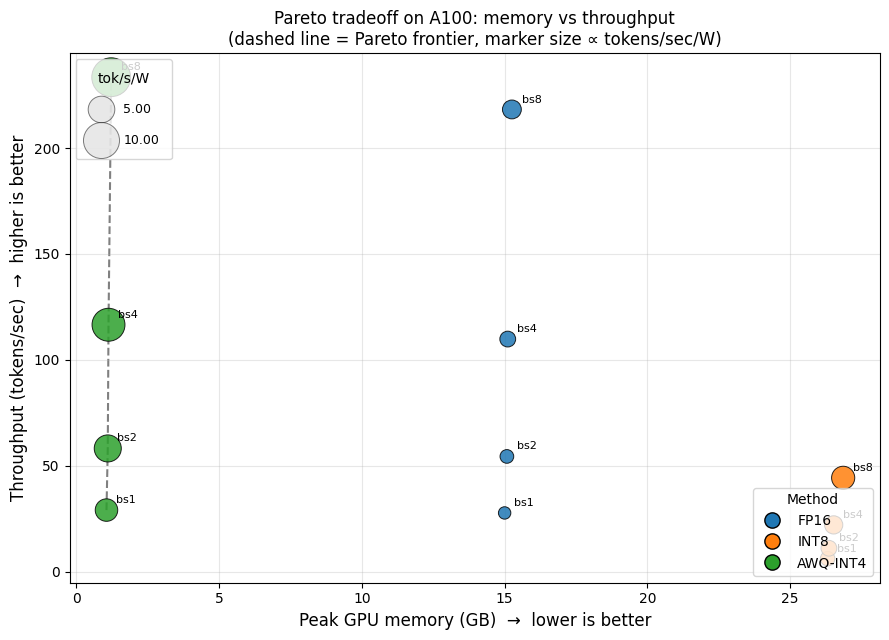

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [14]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

label_map = {"FP16": "FP16", "BNB-INT8": "INT8", "AWQ-Fused": "AWQ-INT4",
             "INT8": "INT8", "AWQ-INT4": "AWQ-INT4"}

if "df_plot" in globals() and "method" in globals()["df_plot"].columns:
    src = df_plot.copy()
elif "df_all" in globals():
    src = df_all.copy(); src["method"] = src["label"].map(label_map).fillna(src["label"])
else:
    src = pd.read_csv("/content/fp16_int8_awq_a100_results.csv")
    src["method"] = src["label"].map(label_map).fillna(src["label"])

src = src.dropna(subset=["peak_memory_gb", "throughput_tok_s"]).copy()
src["batch_size"] = src["batch_size"].astype(int)

# marker size from energy efficiency (tokens/sec/dynamic W)
has_eff = "tok_s_per_dynamic_w" in src.columns and src["tok_s_per_dynamic_w"].notna().any()
if has_eff:
    eff = src["tok_s_per_dynamic_w"].fillna(src["tok_s_per_dynamic_w"].min())
    emin, emax = float(eff.min()), float(eff.max())
    S_MIN, S_RANGE = 80.0, 700.0
    src["msize"] = S_MIN + S_RANGE * (eff - emin) / (emax - emin + 1e-9)
    inv = lambda s: emin + (np.asarray(s) - S_MIN) * (emax - emin) / S_RANGE
else:
    src["msize"] = 200.0  # uniform if efficiency unavailable

# Pareto frontier: maximize throughput, minimize memory (upper-left is best)
def pareto_front(df, x="peak_memory_gb", y="throughput_tok_s"):
    d = df.sort_values([x, y], ascending=[True, False]).reset_index(drop=True)
    keep, best_y = [], -np.inf
    for _, r in d.iterrows():
        if r[y] > best_y:
            keep.append(r); best_y = r[y]
    return pd.DataFrame(keep).sort_values(x)

front = pareto_front(src)

# 4. plot
colors = {"FP16": "#1f77b4", "INT8": "#ff7f0e", "AWQ-INT4": "#2ca02c"}
fig, ax = plt.subplots(figsize=(9, 6.5))

ax.plot(front["peak_memory_gb"], front["throughput_tok_s"],
        "--", color="gray", lw=1.5, zorder=1, label="_nolegend_")

pt_colors = src["method"].map(colors).fillna("#888888")
sc = ax.scatter(src["peak_memory_gb"], src["throughput_tok_s"],
                s=src["msize"], c=pt_colors, alpha=0.85,
                edgecolors="black", linewidths=0.7, zorder=3)

for _, r in src.iterrows():
    ax.annotate(f"bs{r['batch_size']}", (r["peak_memory_gb"], r["throughput_tok_s"]),
                textcoords="offset points", xytext=(7, 5), fontsize=8, color="black")

ax.set_xlabel("Peak GPU memory (GB)  →  lower is better", fontsize=12)
ax.set_ylabel("Throughput (tokens/sec)  →  higher is better", fontsize=12)
ax.set_title("Pareto tradeoff on A100: memory vs throughput\n(dashed line = Pareto frontier"
             + (", marker size ∝ tokens/sec/W)" if has_eff else ")"), fontsize=12)
ax.grid(alpha=0.3)

# color (method)
method_handles = [Line2D([0], [0], marker="o", color="w", label=m,
                         markerfacecolor=c, markeredgecolor="black", markersize=11)
                  for m, c in colors.items() if m in src["method"].values]
leg1 = ax.legend(handles=method_handles, title="Method", loc="lower right", fontsize=10)
ax.add_artist(leg1)

# size (efficiency)
if has_eff:
    handles, _ = sc.legend_elements(prop="sizes", num=3, alpha=0.5, func=inv,
                                    markeredgecolor="black", markerfacecolor="lightgray")
    labels = [f"{inv(h.get_markersize()**2):.2f}" for h in handles]
    ax.legend(handles, labels, title="tok/s/W", loc="upper left",
              labelspacing=1.4, fontsize=9, borderpad=1)

plt.tight_layout()
plt.savefig("/content/pareto_memory_throughput.png", dpi=300, bbox_inches="tight")
plt.show()